In [37]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random

In [38]:
names = open("names.txt",'r').read().splitlines()
chars = sorted(list(set("".join(names))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
g= torch.Generator().manual_seed(42)

In [39]:
def datasetc(words):
  blocks = 3
  x = []
  y = []
  for w in names:
    context = [0]*blocks
    for ch in w + '.':
      ix = stoi[ch]
      x.append(context)
      y.append(ix)
      context = context[1:] + [ix]
  x = torch.tensor(x)
  y = torch.tensor(y)
  return x,y
x,y = datasetc(names[:5])

In [40]:
w1 = torch.randn((6,300),generator=g)
b1 = torch.randn(300,generator=g)
w2 = torch.randn((300,27),generator=g)
b2 = torch.randn(27,generator=g)
C = torch.randn((27,2),generator=g)
parameters = [C,w1,b1,w2,b2]
sum = [p.nelement() for p in parameters]

for p in parameters:
  p.requires_grad = True


In [41]:
lre = torch.linspace(-3,0,1000)
lrs = 10**lre

In [42]:
"""#embe=torch.cat(torch.unbind(emb,1),1) -> inefficient method
lri = []
lossi = []
for i in range(1000):
  lr = lrs[i]
  ix = torch.randint(0,x.shape[0],(32,))
  emb = C[x[ix]]
  h = torch.tanh(emb.view(-1,6)@w1 + b1)
  logits = h@w2+b2
  loss = F.cross_entropy(logits,y)
  for p in parameters:
    p.grad = None
  loss.backward()
  for p in parameters:
     p.data -= p.grad*lr

  lri.append(lre[i])
  lossi.append(loss.item())
print(loss.item())

plt.plot(lri,lossi)"""

'#embe=torch.cat(torch.unbind(emb,1),1) -> inefficient method\nlri = []\nlossi = []\nfor i in range(1000):\n  lr = lrs[i]\n  ix = torch.randint(0,x.shape[0],(32,))\n  emb = C[x[ix]]\n  h = torch.tanh(emb.view(-1,6)@w1 + b1)\n  logits = h@w2+b2\n  loss = F.cross_entropy(logits,y)\n  for p in parameters:\n    p.grad = None\n  loss.backward()\n  for p in parameters:\n     p.data -= p.grad*lr\n\n  lri.append(lre[i])\n  lossi.append(loss.item())\nprint(loss.item())\n\nplt.plot(lri,lossi)'

In [43]:
emb = C[x]
h = torch.tanh(emb.view(-1,6)@w1 + b1)
logits = h@w2+b2
loss = F.cross_entropy(logits,y)
loss

tensor(25.5131, grad_fn=<NllLossBackward0>)

In [44]:
random.seed(42)
random.shuffle(names)
n1 = 0.8*len(names)
n2 = 0.9*len(names)
n1 = int(n1)
n2 = int(n2)
xtrain,ytrain = datasetc(names[:n1])
xval,yval = datasetc(names[n1:n2])
xtest,ytest = datasetc(names[n2:])

In [45]:
print(len(names),n1,n2)

32033 25626 28829


In [56]:
lri = []
lossi = []
stepi = []
for i in range(1000):
  #lr = lrs[i]
  lr=0.1
  ix = torch.randint(0,xtrain.shape[0],(32,))
  emb = C[xtrain[ix]]
  h = torch.tanh(emb.view(-1,6)@w1 + b1)
  logits = h@w2+b2
  loss = F.cross_entropy(logits,ytrain[ix])
  for p in parameters:
    p.grad = None
  loss.backward()
  for p in parameters:
     p.data -= p.grad*lr

  #lri.append(lre[i])
  lossi.append(loss.item())
  stepi.append(i)
print(loss.item())

2.320180892944336


In [57]:
emb = C[xval]
h = torch.tanh(emb.view(-1,6)@w1 + b1)
logits = h@w2+b2
loss = F.cross_entropy(logits,yval)
loss

tensor(2.4302, grad_fn=<NllLossBackward0>)

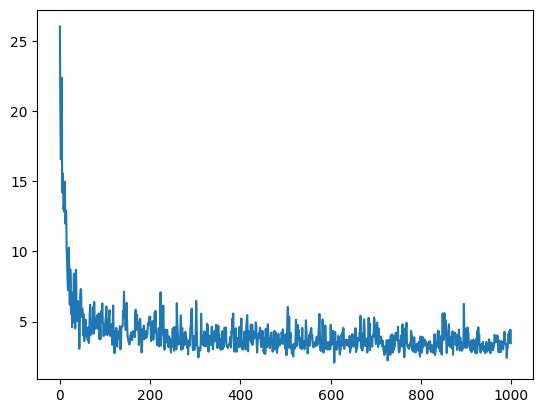

In [48]:
plt.plot(stepi,lossi)

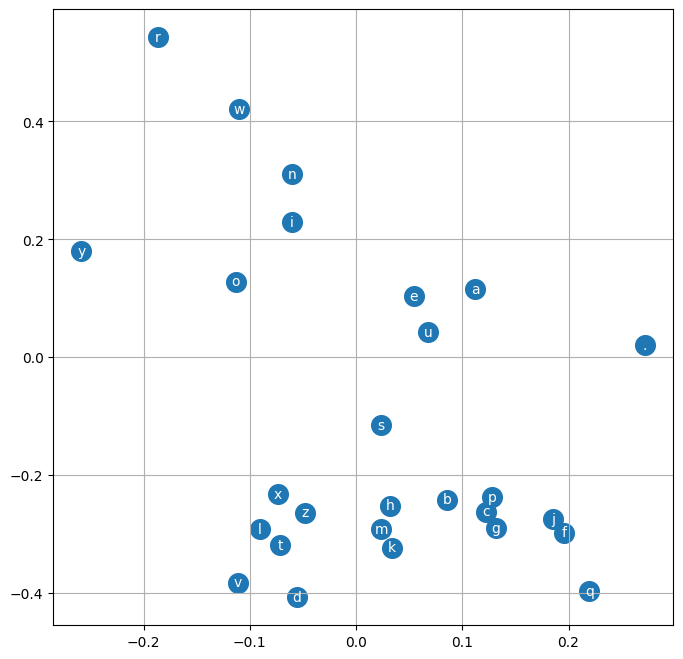

In [49]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [58]:
for _ in range(20):
    out = []
    context = [0]*3
    while True:
      emb = C[torch.tensor([context])]
      h = torch.tanh(emb.view(1, -1) @ w1 + b1)
      logits = h @ w2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    print(''.join(itos[i] for i in out))

trae.
rictordaan.
sali.
rin.
ila.
aracaredilyadalllazabxy.
elie.
zarna.
cukori.
ner.
ler.
ahail.
taxseina.
nawayymh.
omaeah.
jahizila.
lyl.
.
mabta.
keanaylori.
